![](https://www.kaggle.com/competitions/129329/images/header)

<div style="
    padding: 10px;
    background-color: #FFFFFF;
    color:blue;
    border-radius: 3px;
">
<h2>Table of Contents </h2>
    <ol>
        <li>Dataset Overview</li>
        <li>Taxonomy</li>
        <li>Class imbalance</li>
        <li>Recording locations</li>
        <li>Audio quality</li>
        <li>Secondary labels</li>
        <li>Audio visualization</li>
        <li>Spectrogram comparison</li>
        <li>Soundscape labels</li>
        <li>Audio length</li>
    </ol>
</div>


In [1]:
import numpy as np
import pandas as pd
import os
import random

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio

import librosa
import librosa.display

from IPython.display import Audio

sns.set_style("whitegrid")

#-------------------------------------------

DATA_PATH = "/home/mbs/Projects/bird-clef26/data/"
AUDIO_PATH = DATA_PATH + "train_audio/"

<div style="
    padding: 10px;
    background-color: #FFFFFF;
    color:blue;
    border-radius: 3px;
">
<h2>Dataset Overview </h2>
</div>

In [2]:
train = pd.read_csv(DATA_PATH + "train.csv")
taxonomy = pd.read_csv(DATA_PATH + "taxonomy.csv")
labels = pd.read_csv(DATA_PATH + "train_soundscapes_labels.csv")

sample_submission = pd.read_csv(DATA_PATH + "sample_submission.csv")

recording_location = DATA_PATH + "recording_location.txt"

print("train.csv:", train.shape)
print("taxonomy.csv:", taxonomy.shape)
print("train_soundscapes_labels.csv:", labels.shape)
print("sample_submission.csv:", sample_submission.shape)
train.head()

train.csv: (35549, 15)
taxonomy.csv: (234, 5)
train_soundscapes_labels.csv: (1478, 4)
sample_submission.csv: (3, 235)


,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,filename,collection
0,1161364,[],[],-22.7562,-46.8666,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1216197....,1161364/iNat1216197.ogg,iNat
1,1161364,[],[],-22.7558,-46.8700,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1114648....,1161364/iNat1114648.ogg,iNat
2,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/810195.m...,1161364/iNat810195.ogg,iNat
3,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/818781.m...,1161364/iNat818781.ogg,iNat
4,1161364,[],[],-22.7426,-46.8985,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/556514.m...,1161364/iNat556514.ogg,iNat


In [3]:
print("Num species:", train.primary_label.nunique())
print("Collections:")
print(train.collection.value_counts())

Num species: 206
Collections:
collection
XC      23043
iNat    12506
Name: count, dtype: int64


In [4]:
summary = pd.DataFrame({
    "metric": [
        "Number of training clips",
        "Number of unique species in train.csv",
        "Number of classes in taxonomy",
        "Number of soundscape annotations",
        "Number of submission target columns"
    ],
    "value": [
        len(train),
        train["primary_label"].nunique(),
        len(taxonomy),
        len(labels),
        sample_submission.shape[1] - 1
    ]
})

summary

,metric,value
0,Number of training clips,35549
1,Number of unique species in train.csv,206
2,Number of classes in taxonomy,234
3,Number of soundscape annotations,1478
4,Number of submission target columns,234


## 🔎 First impression

A quick sanity check already tells us something important:

- `taxonomy.csv` defines the final target space
- `train.csv` covers clip-level metadata
- `train_soundscapes_labels.csv` is crucial because it is closest to test-time conditions
- submission is **multi-label probability prediction** across **234 species columns**

This means a good competition solution probably cannot rely on `train_audio` alone.

<div style="
    padding: 10px;
    background-color: #FFFFFF;
    color:blue;
    border-radius: 3px;
">
<h2>Taxonomy & Class imbalance</h2>
</div>

In [5]:
taxonomy.head()

,primary_label,inat_taxon_id,scientific_name,common_name,class_name
0,1161364,1161364,Guyalna cuta,Guyalna cuta,Insecta
1,116570,116570,Caiman yacare,Southern Spectacled Caiman,Reptilia
2,1176823,1176823,Leptodactylus luctator,Wrestler Frog,Amphibia
3,1491113,1491113,Adenomera guarani,Guaraní leaf-litter frog,Amphibia
4,1595929,1595929,Lysapsus limellum,Uruguay Harlequin Frog,Amphibia


In [6]:
taxonomy["class_name"].value_counts()

class_name
Aves        162
Amphibia     35
Insecta      28
Mammalia      8
Reptilia      1
Name: count, dtype: int64

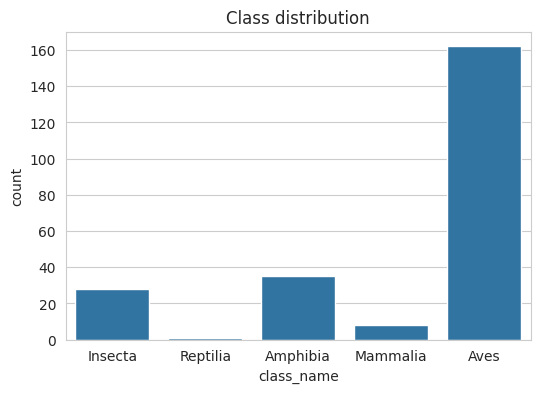

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x="class_name", data=taxonomy)
plt.title("Class distribution")
plt.show()

## Insight

This is not a bird-only challenge.

We are modeling a mixed acoustic ecology problem:
- **Aves**
- **Insecta**
- **Mammalia**
- **Reptilia**
- **Amphibia**

That makes the frequency landscape more diverse and likely increases confusion.


In [8]:
#Merge taxonomy into train
train = train.merge(
    taxonomy[["primary_label", "class_name"]],
    on="primary_label",
    how="left"
)

train.head(2)

,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name_x,inat_taxon_id,author,license,rating,url,filename,collection,class_name_y
0,1161364,[],[],-22.7562,-46.8666,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1216197....,1161364/iNat1216197.ogg,iNat,Insecta
1,1161364,[],[],-22.7558,-46.8700,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1114648....,1161364/iNat1114648.ogg,iNat,Insecta


In [10]:
species_counts = train["primary_label"].value_counts()
pio.renderers.default = 'iframe'
fig = px.histogram(
    x=species_counts.values,
    nbins=50,
    title="Distribution of number of clips per species"
)
fig.update_layout(xaxis_title="Number of training clips for a species",
                  yaxis_title="Count of species")
fig.show()

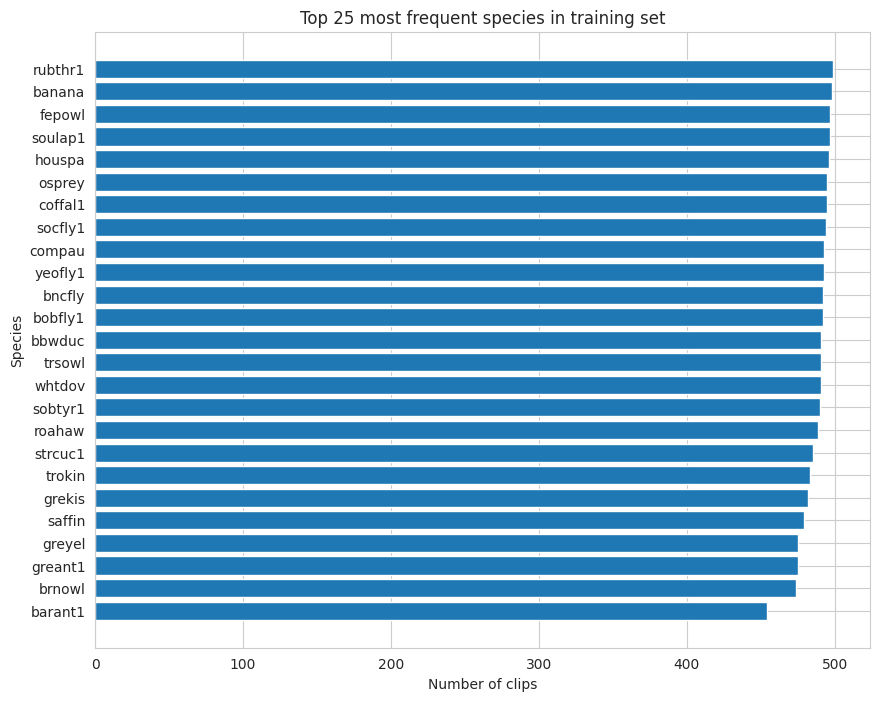

In [11]:
top_species = species_counts.head(25).sort_values()

plt.figure(figsize=(10, 8))
plt.barh(top_species.index, top_species.values)
plt.title("Top 25 most frequent species in training set")
plt.xlabel("Number of clips")
plt.ylabel("Species")
plt.show()

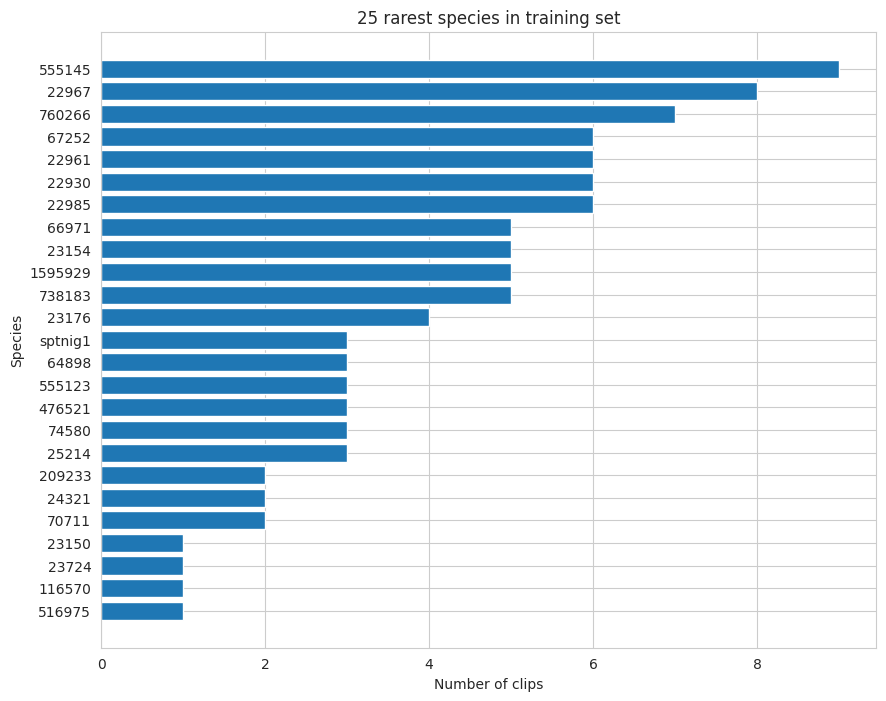

In [12]:
bottom_species = species_counts.tail(25).sort_values()

plt.figure(figsize=(10, 8))
plt.barh(bottom_species.index, bottom_species.values)
plt.title("25 rarest species in training set")
plt.xlabel("Number of clips")
plt.ylabel("Species")
plt.show()

## Insight

The training set is heavily imbalanced.

That matters because:
- common species may dominate optimization
- rare species are easy to underfit
- calibration may be poor on tail classes
- sampling strategy may matter as much as model architecture

Typical responses:
- weighted BCE / focal loss
- class-aware sampling
- oversampling rare classes
- pseudo-labeling from soundscapes

<div style="
    padding: 10px;
    background-color: #FFFFFF;
    color:blue;
    border-radius: 3px;
">
<h2>Recording locations</h2>
</div>

In [13]:
train["collection"].value_counts()

collection
XC      23043
iNat    12506
Name: count, dtype: int64

In [15]:
pio.renderers.default = 'iframe'
fig = px.pie(
    names=train["collection"].value_counts().index,
    values=train["collection"].value_counts().values,
    title="Collection sources in train_audio"
)
fig.show()

In [16]:
pio.renderers.default = 'iframe'


fig = px.scatter_geo(
    train,
    lat="latitude",
    lon="longitude",
    color="collection",
    title="Recording locations"
)

fig.show()

In [17]:
geo = train.dropna(subset=["latitude", "longitude"]).copy()
pio.renderers.default = 'iframe' # lub 'notebook_connected'
fig = px.scatter_geo(
    geo,
    lat="latitude",
    lon="longitude",
    color="class_name_x",
    hover_name="primary_label",
    title="Geographic distribution of recordings",
    opacity=0.7
)
fig.show()

In [18]:
fig = px.scatter_map(
    geo.sample(min(5000, len(geo))),
    lat="latitude",
    lon="longitude",
    color="class_name_x",
    hover_name="primary_label",
    zoom=4,
    map_style="open-street-map",
    title="Sampled recording map"
)
fig.show()

## Insight

Even within one region, geography may still matter.

Possible reasons:
- habitat differences
- local acoustic communities
- temporal activity patterns by site
- call dialects in some bird species

<div style="
    padding: 10px;
    background-color: #FFFFFF;
    color:blue;
    border-radius: 3px;
">
<h2>Audio quality</h2>
</div>

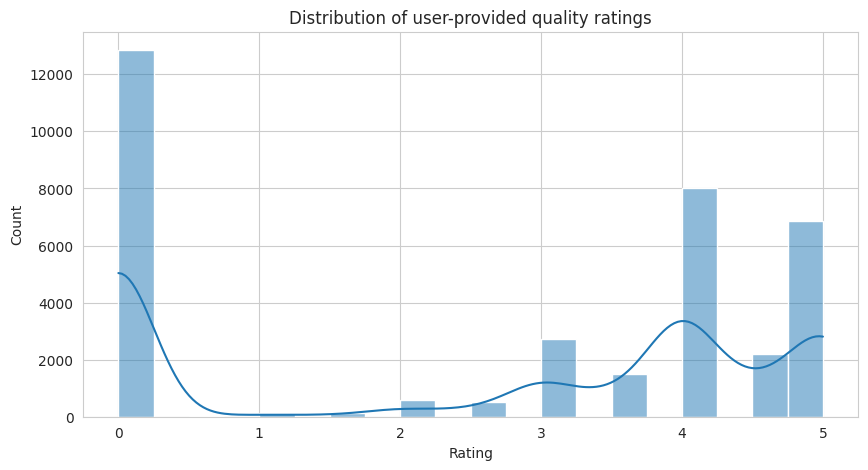

In [19]:
train["rating"] = pd.to_numeric(train["rating"], errors="coerce")

plt.figure(figsize=(10, 5))
sns.histplot(train["rating"].dropna(), bins=20, kde=True)
plt.title("Distribution of user-provided quality ratings")
plt.xlabel("Rating")
plt.show()

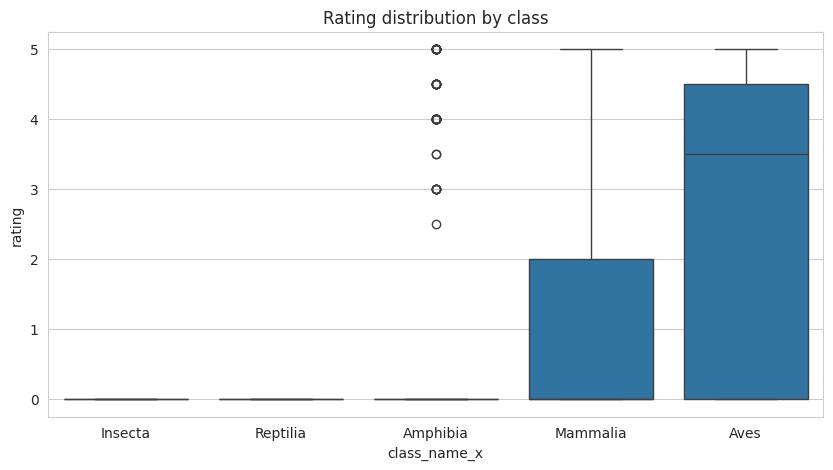

In [20]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=train, x="class_name_x", y="rating")
plt.title("Rating distribution by class")
plt.show()

## Insight

`rating` can be valuable:
- high-rating clips may be useful for cleaner warm-up training
- lower-rating clips may improve robustness

<div style="
    padding: 10px;
    background-color: #FFFFFF;
    color:blue;
    border-radius: 3px;
">
<h2>Secondary labels</h2>
</div>

In [21]:
def parse_secondary_labels(x):
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    try:
        return ast.literal_eval(x)
    except:
        return []

train["secondary_list"] = train["secondary_labels"].apply(parse_secondary_labels)
train["n_secondary"] = train["secondary_list"].apply(len)

train[["primary_label", "secondary_labels", "n_secondary"]].head()

,primary_label,secondary_labels,n_secondary
0,1161364,[],0
1,1161364,[],0
2,1161364,[],0
3,1161364,[],0
4,1161364,[],0


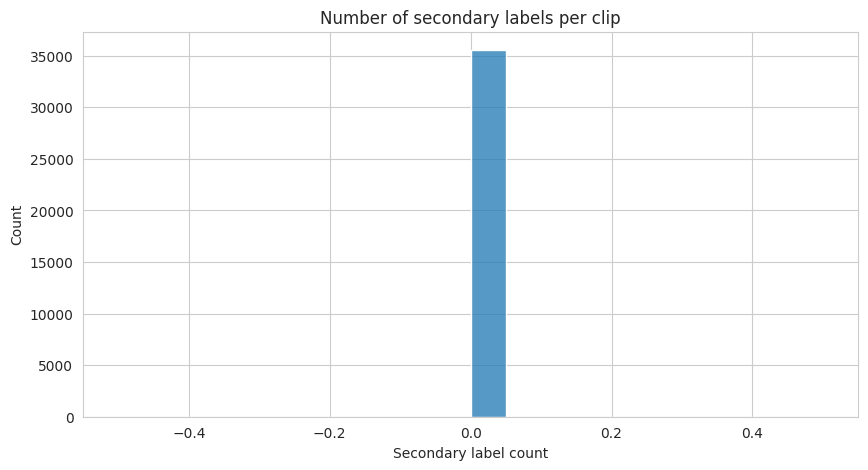

In [22]:
plt.figure(figsize=(10, 5))
sns.histplot(train["n_secondary"], bins=20)
plt.title("Number of secondary labels per clip")
plt.xlabel("Secondary label count")
plt.show()

## Insight
No Secondary labels

<div style="
    padding: 10px;
    background-color: #FFFFFF;
    color:blue;
    border-radius: 3px;
">
<h2>Audio visualization</h2>
</div>

In [23]:
file = train.filename.iloc[0]

path = AUDIO_PATH + file

Audio(path)

/home/mbs/miniconda3/envs/kaggle/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


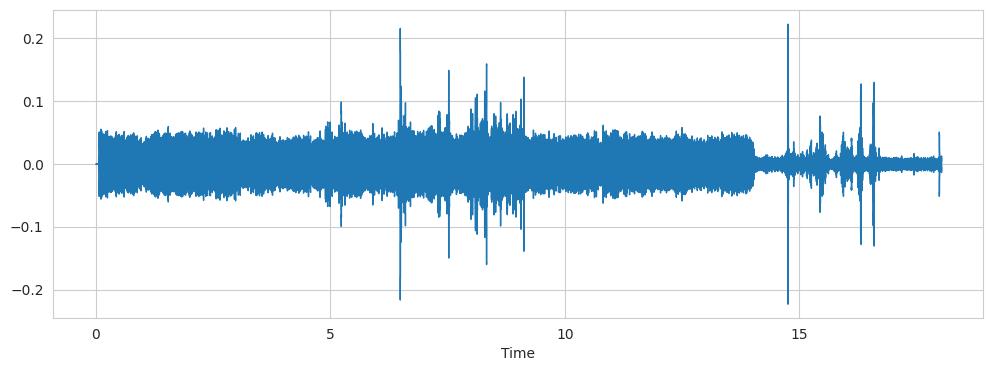

In [24]:
y, sr = librosa.load(path, sr=None)

plt.figure(figsize=(12,4))
librosa.display.waveshow(y, sr=sr)
plt.show()

<div style="
    padding: 10px;
    background-color: #FFFFFF;
    color:blue;
    border-radius: 3px;
">
<h2>Spectrogram comparison</h2>
</div>

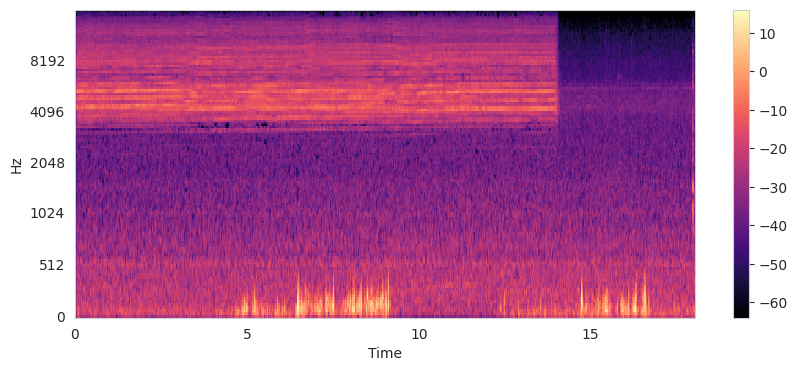

In [25]:
S = librosa.feature.melspectrogram(y=y, sr=sr)
S_db = librosa.power_to_db(S)

plt.figure(figsize=(10,4))
librosa.display.specshow(
    S_db,
    sr=sr,
    x_axis="time",
    y_axis="mel"
)
plt.colorbar()
plt.show()

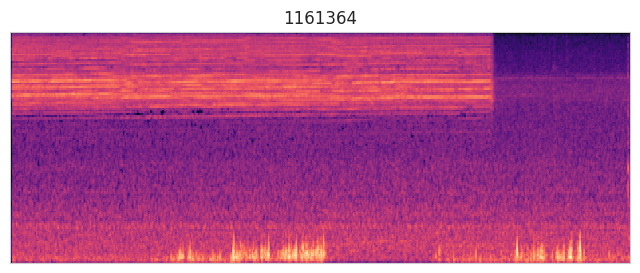

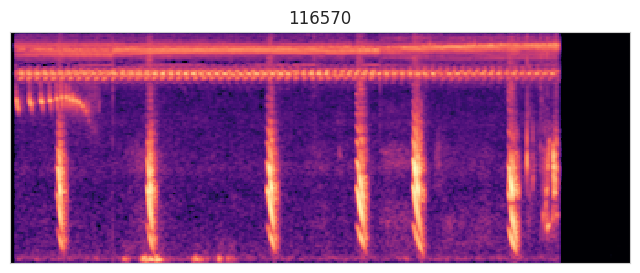

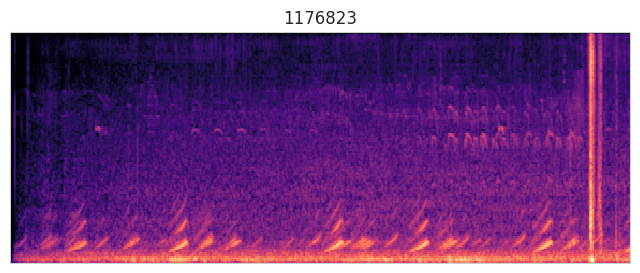

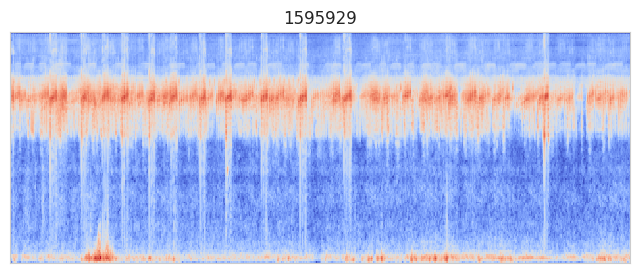

In [26]:
samples = train.primary_label.unique()[:4]

for sp in samples:

    f = train[train.primary_label == sp].filename.iloc[0]

    y, sr = librosa.load(AUDIO_PATH + f)

    S = librosa.feature.melspectrogram(y=y, sr=sr)
    S_db = librosa.power_to_db(S)

    plt.figure(figsize=(8,3))
    librosa.display.specshow(S_db, sr=sr)
    plt.title(sp)
    plt.show()

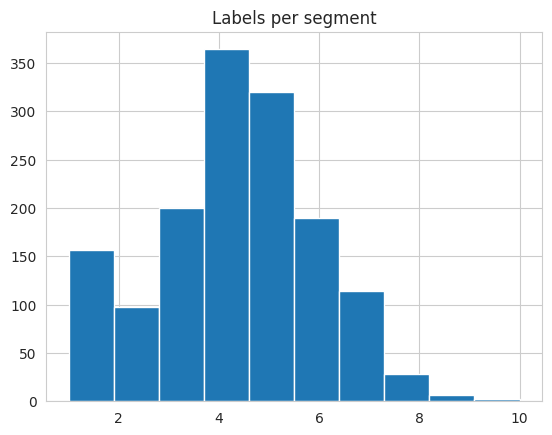

In [27]:
labels.head()

labels["num_labels"] = labels.primary_label.str.split(";").apply(len)

plt.hist(labels.num_labels)
plt.title("Labels per segment")
plt.show()

In [28]:
labels["end"] = pd.to_timedelta(labels["end"])
labels["start"] = pd.to_timedelta(labels["start"])

labels["duration"] = labels["end"] - labels["start"]

In [29]:
labels["duration_seconds"] = labels["duration"].dt.total_seconds()
labels.duration_seconds.value_counts()

duration_seconds
5.0    1478
Name: count, dtype: int64

In [30]:
labels.head()

,filename,start,end,primary_label,num_labels,duration,duration_seconds
0,BC2026_Train_0039_S22_20211231_201500.ogg,0 days 00:00:00,0 days 00:00:05,22961;23158;24321;517063;65380,5,0 days 00:00:05,5.0
1,BC2026_Train_0039_S22_20211231_201500.ogg,0 days 00:00:05,0 days 00:00:10,22961;23158;24321;517063;65380,5,0 days 00:00:05,5.0
2,BC2026_Train_0039_S22_20211231_201500.ogg,0 days 00:00:10,0 days 00:00:15,22961;23158;24321;517063;65380,5,0 days 00:00:05,5.0
3,BC2026_Train_0039_S22_20211231_201500.ogg,0 days 00:00:15,0 days 00:00:20,22961;23158;24321;517063;65380,5,0 days 00:00:05,5.0
4,BC2026_Train_0039_S22_20211231_201500.ogg,0 days 00:00:20,0 days 00:00:25,22961;23158;24321;517063;65380,5,0 days 00:00:05,5.0


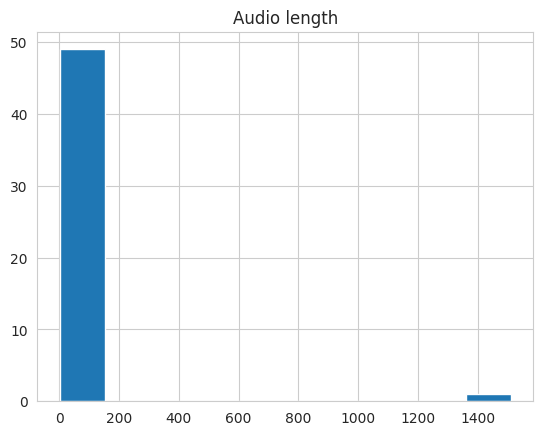

In [31]:
files = random.sample(list(train.filename), 50)

lengths = []

for f in files:
    y, sr = librosa.load(AUDIO_PATH + f)
    lengths.append(len(y)/sr)

plt.hist(lengths)
plt.title("Audio length")
plt.show()